<br>
<a href="https://www.nvidia.com/en-us/training/">
    <div style="width: 55%; background-color: white; margin-top: 50px;">
    <img src="https://dli-lms.s3.amazonaws.com/assets/general/nvidia-logo.png"
         width="400"
         height="186"
         style="margin: 0px -25px -5px; width: 300px"/>
    </div>
</a>
<h1 style="line-height: 1.4;"><font color="#76b900"><b>Rapid Application Development<br>using Large Language Models</b></h1>
<h2><b>Notebook 8:</b> Course Assessment</h2>
<br>

**Congratulations On (Almost) Finishing The Course!** 

We hope you've enjoyed the journey and have gained valuable skills to get starting with building novel and interesting language-guided applications. Now, it's time to put those skills to the test for an assessment! In previous sections, we've explored various aspects of language models, including data pipelining tools, visual language models (VLMs), and diffusion models. An assessment prep notebook is also available (see notebook 7.5) which can help with this exercise! In this assessment, we'll bring all these concepts together to build an interesting application that you likely take for granted if you've ever used an image generator.

### **Setup**

Before we begin, let's set up our environment by importing the necessary libraries and initializing our language model.

In [1]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA

model_path = "http://127.0.0.1:9004/v1"
%env NVIDIA_BASE_URL=$model_path
%env NVIDIA_DEFAULT_MODE=open

model_name = "nvidia/NVIDIA-Nemotron-Nano-12B-v2-VL-BF16"

## Maybe you'll need more connectors? Maybe you'll need a different endpoint (this one may be down)? 
llm = ChatNVIDIA(
    model=model_name, 
    base_url=model_path, 
    max_completion_tokens=5000, 
    temperature=0
)

env: NVIDIA_BASE_URL=http://127.0.0.1:9004/v1
env: NVIDIA_DEFAULT_MODE=open


<hr>
<br>

## **Part 8.1:** Assessment

For the course assessment, you will be implementing a common feature that usually sits behind the API of an image-generating endpoint; **synthetic prompts**.

When creating text-conditioned diffusion models, developers usually create synthetic keyword-rich datasets for training that allow the model to learn strong customization priors. 
- **In an ideal scenario,** an image generator could be prompted to generate a truly-arbitrary high-quality image that perfectly fits any natural-language prompt - as long as the prompt itself is expressive enough.
- **In practice,** image generators are prompted - and sometimes trained - with loose directives and the model makes sprawling assumptions about the details based on its training data. This commonly manifests as "image retrieval," where training data with only minor modifications gets produced.

Most providers would be more interested in giving people the freedom to prompt the model however they want, so many choose to incorporate text-to-text interfaces that map from "regular human prompt" to "diffusion input prompt" space. 

### **Exercise:** Image-Inspired Generation

For the course exercise, you will implement a potential schema that combines synthetic prompts with vision to "create images inspired by another image." The process is broken down into tasks below, and will need to be incorporated at the end to pass the assessment. 

<div><img src="imgs/rad-assessment.png" width="800"/></div>

**NOTE:** Tasks 1 through 3 are merely building blocks to implement the final solution in Task 4. Only the results of Task 4 will be graded. Feel free to skip tasks 1 through 3 if you are confident that it will not necessary.

<hr>
<br>

### **[Task 1]** Image Ingestion

First off, we need to be able to take in and reason about an image. To do this, implement the `ask_about_image` method below:

**Simplifying Assumptions:**
- It shouldn't be too hard to have your LLM predict both a question and an image file, but feel free to hardcode the question instead.
- It's generally best to leverage some combination of batching, caching, grouping, and preprocessing depending on how frequently your image pool gets updated. Feel free to forego such optimizations.
- LangChain connectors like `ChatNVIDIA` and `ChatOpenAI` do actually provide a streamlined interface, but feel free to recycle the requests code from before. Whatever's easiest.

**HINTS:**
- Recall your learnings from the VLM spinup in notebook 6. Perhaps we could use that model? Is it still up?
- More of a note, but some models like GPT-4o are extremely strong as both chat and image-reasoning models.
- If you run out of cuda memory, it sounds like you might be over-allocating something. Try restarting your kernels. 

In [2]:
import requests
import base64
import mimetypes

def ask_about_image(image_path: str, question: str = "Describe the image") -> str:
    ####################################################################
    ## < EXERCISE SCOPE

    # 1. Leer y convertir la imagen a Base64
    with open(image_path, "rb") as img_file:
        encoded_string = base64.b64encode(img_file.read()).decode("utf-8")

    mime_type, _ = mimetypes.guess_type(image_path)
    mime_type = mime_type or "image/png"
    image_data_url = f"data:{mime_type};base64,{encoded_string}"

    # 2. Construir el payload compatible con OpenAI / vLLM
    payload = {
        "model": "nvidia/NVIDIA-Nemotron-Nano-12B-v2-VL-BF16",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": question},
                    {"type": "image_url", "image_url": {"url": image_data_url}}
                ]
            }
        ],
        "max_tokens": 5000,
        "temperature": 0
    }

    # 3. Enviar la solicitud POST al servidor local
    endpoint = "http://127.0.0.1:9004/v1/chat/completions"
    response = requests.post(endpoint, json=payload)
    
    response.raise_for_status()
    return response.json()["choices"][0]["message"]["content"]

    ## EXERCISE SCOPE >
    ####################################################################

description = ask_about_image("imgs/agent-overview.png", "Describe the image")
print(description)

The image presents a flowchart that illustrates the process of an agent's decision-making. The flowchart is divided into several sections, each representing a different aspect of the agent's cognitive process.

At the top, there are two main sections: "Short-term memory" and "Long-term memory". These sections are connected by arrows, indicating the flow of information between them.

Below these sections, there are several other components that make up the agent's decision-making process. These include "Tools", "Agent", "Planning", "Reflection", "Self-critics", "Chain of thoughts", and "Subgoal decomposition". Each of these components is connected to the others by arrows, showing the flow of information and decision-making within the agent.

The "Tools" section includes various tools such as "Calendar", "Calculator", "CodeInterpreter", and "Search". These tools are likely used by the agent to gather information and make decisions.

The "Agent" section is the central component of the flo

<hr>
<br>

### **[Task 2]** Image Creation

Now that we have our image descriptions, let's try to generate an image based on this response:

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['between them. below these sections, there are several other components that make up the agent\'s decision - making process. these include " tools ", " agent ", " planning ", " reflection ", " self - critics ", " chain of thoughts ", and " subgoal decomposition ". each of these components is connected to the others by arrows, showing the flow of information and decision - making within the agent. the " tools " section includes various tools such as " calendar ", " calculator ", " codeinterpreter ", and " search ". these tools are likely used by the agent to gather information and make decisions. the " agent " section is the central component of the flowchart, representing the agent itself. it is connected to the " tools " section, indicating that the agent uses these tools to make decisions. the " planning " section is connected to the " agent " section, suggesting that the agent use

  0%|          | 0/50 [00:00<?, ?it/s]

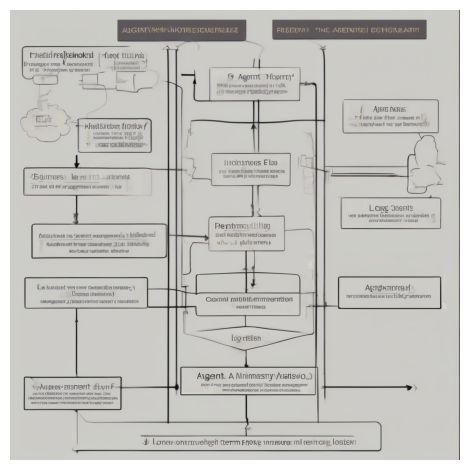

In [35]:
from diffusers import DiffusionPipeline
import torch
import matplotlib.pyplot as plt
import json

base_path = '/dli/task/generated_images/'

## TODO: Implement this method as appropriate
def generate_images(prompt: str, n: int = 1):
    ####################################################################
    ## < EXERCISE SCOPE
    pipe = DiffusionPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-base-1.0",
        torch_dtype=torch.float16,
        use_safetensors=True,
        variant="fp16"
    ).to("cuda")

    prompt_description = f"Generate a SHORT description with no SPACES, using only HYPHENS, based on a prompt. Example: “the-cat-runs-along-the-sidewalk” Prompt:{prompt}"

    payload = {
        "model": "nvidia/NVIDIA-Nemotron-Nano-12B-v2-VL-BF16",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt_description},
                ]
            }
        ],
        "max_tokens": 50,
        "temperature": 0
    }

    # 3. Enviar la solicitud POST al servidor local
    endpoint = "http://127.0.0.1:9004/v1/chat/completions"
    response = requests.post(endpoint, json=payload).text
    name = json.loads(response)['choices'][0]['message']['content'].strip()

    # Pasar una lista con múltiples prompts
    prompts = [prompt] * n

    images = []

    for idx, image in enumerate(pipe(prompt=prompts).images):
        path = f'{base_path}{name}-{idx}.png'
        image.save(path)
        images.append(path)

    return images
    ## EXERCISE SCOPE >
    ####################################################################

def plot_imgs(images, r=2, c=2):
    fig, axes = plt.subplots(r, c)
    for i, ax in enumerate(getattr(axes, "flat", [axes])):
        img = plt.imread(images[i])
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

images = generate_images(description)
plot_imgs(images, 1, 1)

<hr>
<br>

### **[Task 3]** Prompt Synthesis

After an initial attempt, you should notice that this type of description is far too complex. Perhaps we can get better results if we connect these two disparate components with an LLM-enabled interface?

In the abstract, this interface is helping to map from the VLM output domain to the Diffusion input domain, but could have been done between just about any two function specifications. **In more simple terms, we're trying to map from VLM description to Diffusion prompt using an intermediate step.**

In [9]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from langchain_nvidia import ChatNVIDIA
from pydantic import BaseModel, Field

class ResponsePromtps(BaseModel):
    
    prompts: list[str] = Field(min_length=1)

parser = PydanticOutputParser(pydantic_object=ResponsePromtps)

system_prompt= """
You are an expert Diffusion Image Prompt Engineer and Creative Art Director. Your task is to take a raw input concept/prompt and expand it into N highly detailed, distinct, and production-ready synthetic prompts optimized for text-to-image diffusion models (e.g., Stable Diffusion XL, Midjourney, Flux, DALL-E 3).

### CORE RULES FOR PROMPT SYNTHESIS:
1. Language: Output all synthetic image prompts strictly in English, as diffusion models perform best in English.
2. Structure of Each Image Prompt:
   - Subject: Clear, vivid description of the main object/character/scene.
   - Medium & Style: Specify artistic medium (e.g., 35mm photograph, digital painting, 3D Octane render, watercolor, concept art).
   - Environment & Background: Specific setting, atmosphere, depth of field.
   - Lighting & Color: Type of lighting (e.g., volumetric lighting, golden hour, moody chiaroscuro, cinematic neon) and palette.
   - Camera & Optics (if realistic): Lens size, aperture, angle (e.g., 85mm f/1.4, wide-angle, macro, low-angle shot).
   - Technical Descriptors: Texture and detail details (e.g., highly detailed, photorealistic, intricate, octane render, 8k resolution).

3. Diversity Requirement:
   - Ensure the N prompts explore DIFFERENT visual interpretations, art styles, moods, compositions, and lighting setups, while retaining the core intent of the original concept.

{format_instructions}
"""

llm = ChatNVIDIA(
        model="nvidia/NVIDIA-Nemotron-Nano-12B-v2-VL-BF16",
        base_url='http://127.0.0.1:9004/v1',
        max_completion_tokens=5000, 
        temperature=0
    )

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("user", "Base concept: \"{concept}\"\nNumber of prompts to generate (N): {n}"),
])

chain = prompt | llm | parser

def llm_rewrite_to_image_prompts(user_query: str, n: int = 4) -> list[str]:

    ####################################################################
    ## < EXERCISE SCOPE
    
    ## TODO: Create a pipeline for synthetic prompts, optputting a string.
    sd_prompts = chain.invoke({
        "concept": user_query,
        "n": n,
        "format_instructions": parser.get_format_instructions()
    }).prompts
    
    assert len(sd_prompts) == n
    return sd_prompts
    
    ## EXERCISE SCOPE >
    ####################################################################

new_sd_prompts = llm_rewrite_to_image_prompts(description)
new_sd_prompts

["A detailed flowchart illustrating an agent's decision-making process, featuring interconnected sections for short-term and long-term memory, tools (calendar, calculator, code interpreter, search), agent, planning, reflection, self-criticism, chain of thoughts, and subgoal decomposition, rendered in a clean technical diagram style with labeled arrows showing information flow, on a white background with blue and gray color scheme",
 "A stylized 3D Octane render of a decision-making agent's cognitive architecture, showcasing layered memory systems (short-term and long-term) connected to a central agent node, surrounded by interactive tools (calendar, calculator, code interpreter, search), with dynamic arrows and glowing connections between planning, reflection, self-criticism, chain of thoughts, and subgoal decomposition modules, in a futuristic tech aesthetic with metallic textures and neon accents",
 "A hand-drawn concept art illustration of an agent's decision-making flowchart, featu

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['white background with blue and gray color scheme']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['white background with blue and gray color scheme']


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['with earthy tones and subtle texture']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['with earthy tones and subtle texture']


  0%|          | 0/50 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['of field highlighting the central agent node, natural lighting, and visible pencil annotations for authenticity']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['of field highlighting the central agent node, natural lighting, and visible pencil annotations for authenticity']


  0%|          | 0/50 [00:00<?, ?it/s]

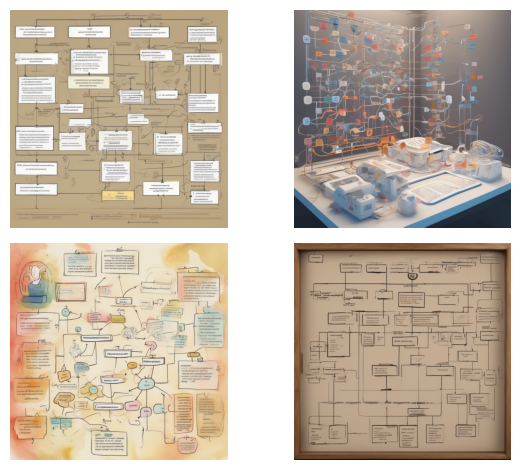

In [10]:
images = [generate_images(sd_prompt)[0] for sd_prompt in new_sd_prompts]
plot_imgs(images)

<hr>
<br>

### **[Task 4]** Pipelining and Iterating

**To finish the assessment, incorporate these tasks into a pipeline to make the following process turn-key:**
- **Take in an image from the compute environment.**
- **Compute a summary of the image.**
- **Use an LLM to create four different synthetic prompts for the image generation pipeline.**
- **Produce four distinct images that you are happy with.**

**NOTES:**
- Feel free to implement it as either a standard function or a chain.
- Return the saved image paths. You can optionally display the images as well.
- To speed up prompt generation, we recommend trying out parallel processes and batching. The image server processes one image at a time. 

Generating images for imgs/agent-overview.png


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['white background with blue and gray color scheme']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['white background with blue and gray color scheme']


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


...

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['with earthy tones and subtle texture']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['with earthy tones and subtle texture']


  0%|          | 0/50 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['of field highlighting the central agent node, natural lighting, and visible pencil annotations for authenticity']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['of field highlighting the central agent node, natural lighting, and visible pencil annotations for authenticity']


  0%|          | 0/50 [00:00<?, ?it/s]

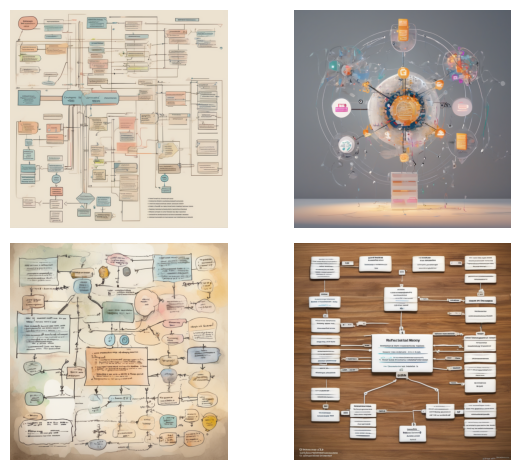

Generating images for imgs/multimodal.png


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['column ( animation, molecule, protein, dna, video, 3 d, image, audio, text ) in muted pastels. the scene is illuminated by soft volumetric lighting, with subtle lens flare effects and 8 k resolution details.']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['column ( animation, molecule, protein, dna, video, 3 d, image, audio, text ) in muted pastels. the scene is illuminated by soft volumetric lighting, with subtle lens flare effects and 8 k resolution details.']


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


...

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["fisheye lens effect, with soft focus on the background stars and hyper - detailed brushstrokes on the satellite's surface."]
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["fisheye lens effect, with soft focus on the background stars and hyper - detailed brushstrokes on the satellite's surface."]


  0%|          | 0/50 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["a low - angle shot with a 2 4 mm lens, dramatic rim lighting, and intricate reflections on the satellite's surface, rendered in 1 6 k resolution."]
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["a low - angle shot with a 2 4 mm lens, dramatic rim lighting, and intricate reflections on the satellite's surface, rendered in 1 6 k resolution."]


  0%|          | 0/50 [00:00<?, ?it/s]

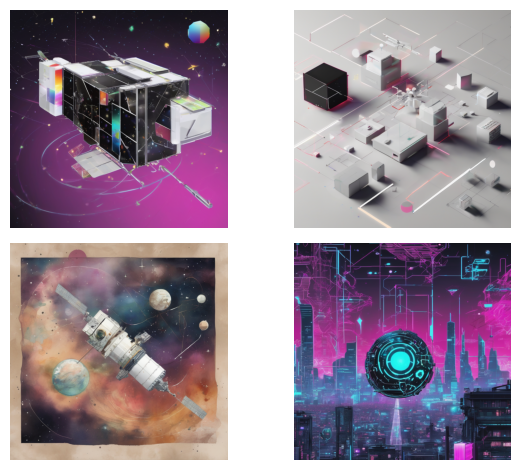

Generating images for img-files/tree-frog.jpg


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

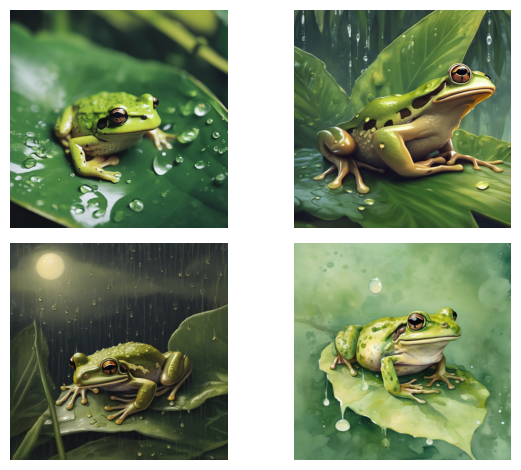

Generating images for img-files/paint-cat.jpg


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['a photorealistic style with soft lighting and shallow depth of field, 8 5 mm lens, f / 2. 8 aperture, 8 k resolution.']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['a photorealistic style with soft lighting and shallow depth of field, 8 5 mm lens, f / 2. 8 aperture, 8 k resolution.']


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


...

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['metric lighting effect, with a wide - angle perspective.']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['metric lighting effect, with a wide - angle perspective.']


  0%|          | 0/50 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['and diffused.']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['and diffused.']


  0%|          | 0/50 [00:00<?, ?it/s]

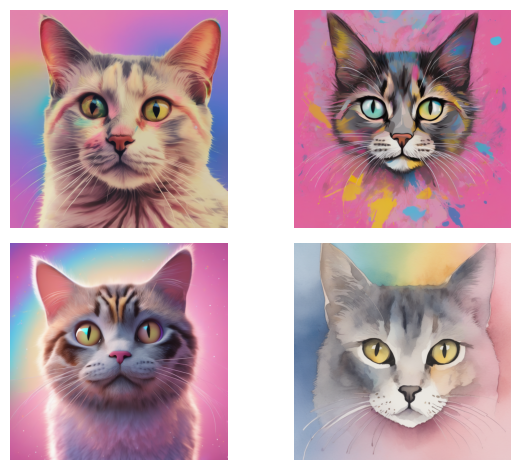

In [36]:
## TODO: Execute on assessment objective
def generate_images_from_image(image_url: str, num_images = 4):

    print(f"Generating images for {image_url}")

    ####################################################################
    ## < EXERCISE SCOPE

    ## TODO: Generate the description of the image provided in image_url
    original_description = ask_about_image(image_url)

    ## TODO: Generate four disjoint prompts, hopefully different, to feed into SDXL
    diffusion_prompts = llm_rewrite_to_image_prompts(original_description, num_images)

    ## TODO: Generate the resulting images
    generated_images = [generate_images(sd_prompt)[0] for sd_prompt in diffusion_prompts]

    ## EXERCISE SCOPE >
    ####################################################################

    plot_imgs(generated_images)
    return generated_images, diffusion_prompts, original_description

results = []
results += [generate_images_from_image("imgs/agent-overview.png")]
results += [generate_images_from_image("imgs/multimodal.png")]
results += [generate_images_from_image("img-files/tree-frog.jpg")]
results += [generate_images_from_image("img-files/paint-cat.jpg")]

<hr>
<br>

## **Part 8.2:** Running The Assessment

To assess your submission, run the following cells to save your results and the one after to query the assessment runner.

**Follow the instructions and make sure it all passes.**

In [37]:
import os
import json
import requests
from PIL import Image
import re

def send_metadata(results):    
    
    save_dir="generated_images"
    
    # Collect all image paths and metadata
    all_metadata = []

    for result in results:
        image_paths, prompts, original_description = result
        
        # Append metadata for the current batch
        all_metadata.append({
            "original_description": original_description,
            "prompts": prompts,
            "image_paths": [path.replace("/dli/task/", "") for path in image_paths]
        })
    
    # Save all metadata in a single JSON file
    metadata_path = os.path.join(save_dir, "all_metadata.json")
    with open(metadata_path, 'w') as f:
        json.dump(all_metadata, f, indent=4)
    return all_metadata

## Generate your submission
submission = send_metadata(results)

## Send the submission over to the assessment runner
response = requests.post(
    "http://docker_router:8070/run_assessment", 
    json={"submission": submission},
)

response.raise_for_status()

try: 
    print(response.json().get("result") or "<No Results>")
    print(response.json().get("messages") or "<No More Messages>")
    print(response.json().get("exceptions") or "<No Exceptions>")
except:
    print(response.__dict__)

Congratulations! You passed the assessment!
See instructions below to generate a certificate.
<No More Messages>
<No Exceptions>


<br>

If you passed the assessment, please return to the course page (shown below) and click the **"ASSESS TASK"** button, which will generate your certificate for the course.

<img src="./imgs/assess_task.png" style="width: 800px;">


<hr>
<br>

## **Part 8.3:** Wrapping Up

### <font color="#76b900">**Congratulations On Completing The Course!!**</font>

Before concluding the course, we highly recommend downloading the course material for later reference, and checking over the **"Next Steps"** and **Feedback** sections of the course. **We appreciate you taking the time to go through the course, and look forward to seeing you again for the next courses in the series!**

<a href="https://www.nvidia.com/en-us/training/">
    <div style="width: 55%; background-color: white; margin-top: 50px;">
    <img src="https://dli-lms.s3.amazonaws.com/assets/general/nvidia-logo.png"
         width="400"
         height="186"
         style="margin: 0px -25px -5px; width: 300px"/>
    </div>
</a>